<a href="https://colab.research.google.com/github/Wahdaapf/PCVK_Ganjil_2026/blob/main/Week7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math
from google.colab.patches import cv2_imshow
from PIL import Image as im

In [4]:
img = cv.imread('/content/drive/MyDrive/Google Collab/Lenna.png')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

In [5]:
#image sharpen
kernel_sharpen = np.array([[0,-1,0],
                           [-1,5,-1],
                           [0,-1,0]])

In [9]:
def convolution2d(image, kernel, stride, padding):
    # Ukuran gambar dan kernel
    image_height, image_width = image.shape
    kernel_height, kernel_width = kernel.shape

    # Menambahkan padding pada gambar
    padded_image = np.pad(
        image,
        ((padding, padding), (padding, padding)),
        mode='constant',
        constant_values=0
    )

    # Ukuran output
    output_height = ((image_height + 2 * padding - kernel_height) // stride) + 1
    output_width = ((image_width + 2 * padding - kernel_width) // stride) + 1

    # Membuat matriks output
    output = np.zeros((output_height, output_width))

    # Proses konvolusi
    for i in range(0, output_height):
        for j in range(0, output_width):

            # Menentukan posisi kernel
            row_start = i * stride
            row_end = row_start + kernel_height

            col_start = j * stride
            col_end = col_start + kernel_width

            # Mengambil bagian gambar sesuai ukuran kernel
            image_region = padded_image[row_start:row_end, col_start:col_end]

            # Perkalian elemen gambar dengan kernel
            output[i, j] = np.sum(image_region * kernel)

    return output

In [10]:
convolution2d(img_gray, kernel_sharpen, 1, 2)

array([[   0., -162., -162., ..., -155., -128.,    0.],
       [-162.,  486.,  324., ...,  322.,  357., -128.],
       [-162.,  324.,  162., ...,  167.,  229., -128.],
       ...,
       [ -44.,   89.,   34., ...,  108.,  229., -108.],
       [ -44.,  132.,   77., ...,  208.,  327., -108.],
       [   0.,  -44.,  -44., ..., -105., -108.,    0.]])

In [15]:
# Average Filter
kernel_average = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
])

hasil_average = convolution2d(img_gray, kernel_average, 1, 1)


# Low Pass Filter
kernel_lowpass = np.array([
    [-2, -1, 0],
    [-1, 1, 1],
    [0, 1, 2]
])

hasil_lowpass = convolution2d(img_gray, kernel_lowpass, 1, 1)


# High Pass Filter
kernel_highpass = np.array([
    [1, 0, -1],
    [2,  0, -2],
    [1, 0, -1]
])

hasil_highpass = convolution2d(img_gray, kernel_highpass, 1, 1)


# Sharpen Filter
kernel_sharpen = np.array([
    [-1, -1, -1],
    [-1, 8, -1],
    [-1, -1, -1]
])

hasil_sharpen = convolution2d(img_gray, kernel_sharpen, 1, 1)

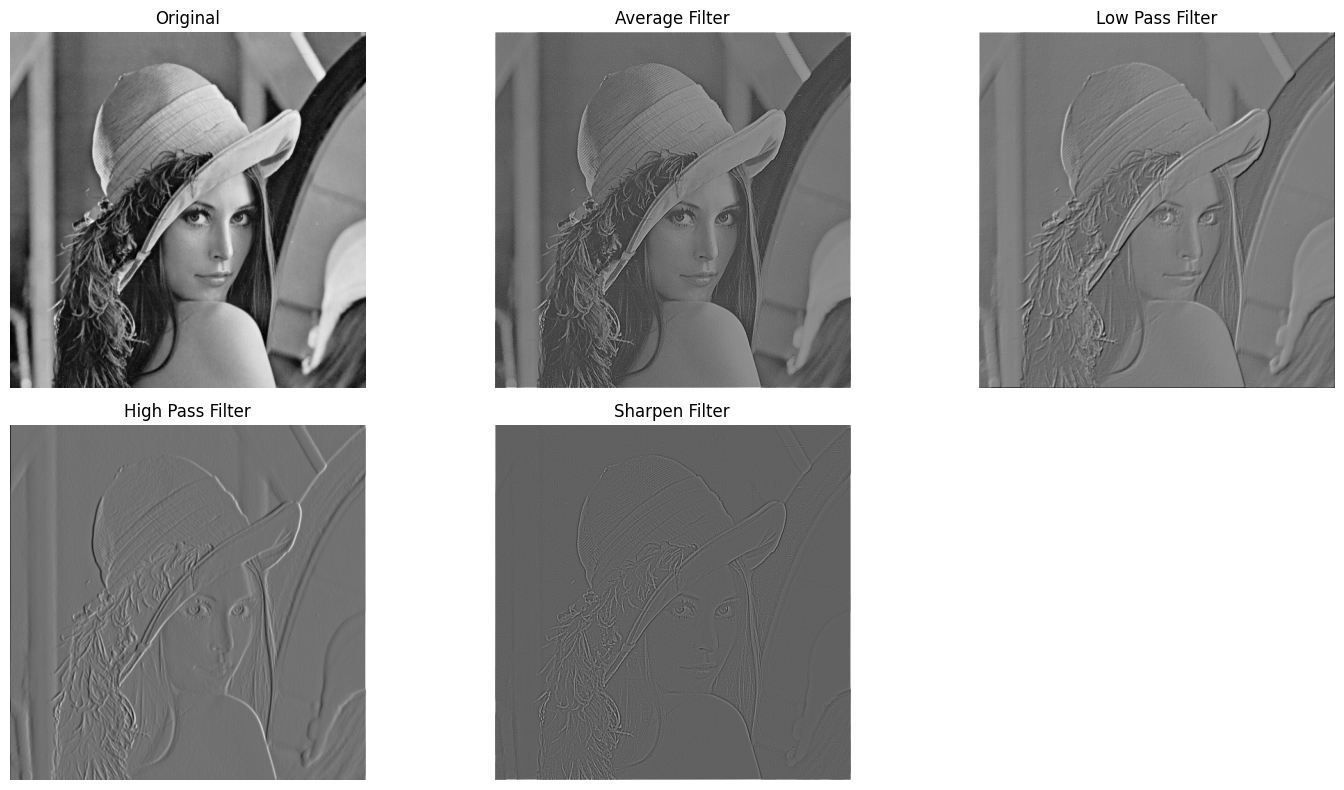

In [16]:
plt.figure(figsize=(15, 8))

# Original
plt.subplot(2, 3, 1)
plt.imshow(img_gray, cmap='gray')
plt.title('Original')
plt.axis('off')

# Average
plt.subplot(2, 3, 2)
plt.imshow(hasil_average, cmap='gray')
plt.title('Average Filter')
plt.axis('off')

# Low Pass
plt.subplot(2, 3, 3)
plt.imshow(hasil_lowpass, cmap='gray')
plt.title('Low Pass Filter')
plt.axis('off')

# High Pass
plt.subplot(2, 3, 4)
plt.imshow(hasil_highpass, cmap='gray')
plt.title('High Pass Filter')
plt.axis('off')

# Sharpen
plt.subplot(2, 3, 5)
plt.imshow(hasil_sharpen, cmap='gray')
plt.title('Sharpen Filter')
plt.axis('off')

plt.tight_layout()
plt.show()

In [17]:
# Fungsi tampil berdampingan
def show_side_by_side(images, titles, figsize=(15, 5)):
    plt.figure(figsize=figsize)

    for i, (img, title) in enumerate(zip(images, titles)):
        if len(img.shape) == 2:  # grayscale
            plt.subplot(1, len(images), i + 1)
            plt.imshow(img, cmap="gray")
        else:  # color
            plt.subplot(1, len(images), i + 1)
            plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))

        plt.title(title)
        plt.axis("off")

    plt.show()

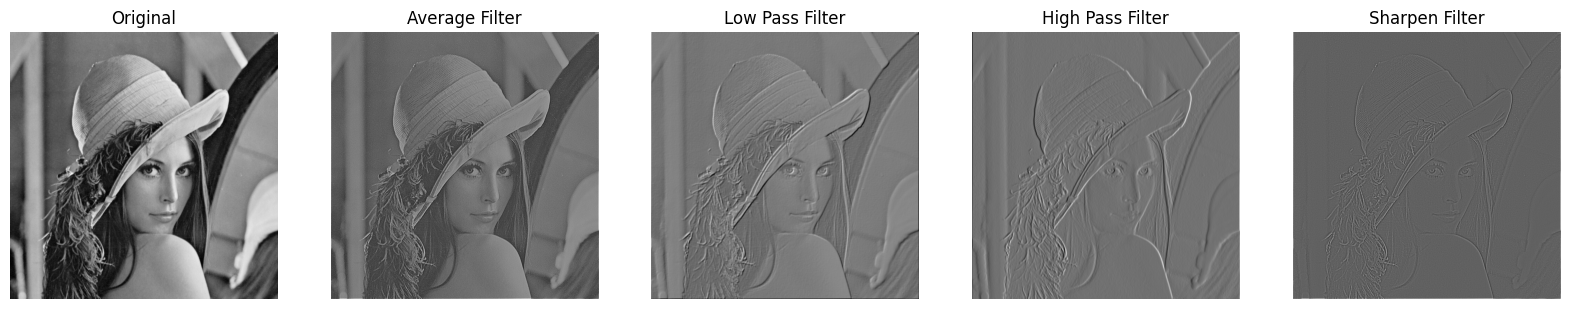

In [18]:
show_side_by_side(
    [
        img_gray,
        hasil_average,
        hasil_lowpass,
        hasil_highpass,
        hasil_sharpen
    ],
    [
        "Original",
        "Average Filter",
        "Low Pass Filter",
        "High Pass Filter",
        "Sharpen Filter"
    ],
    figsize=(20, 5)
)

#Percobaan 1

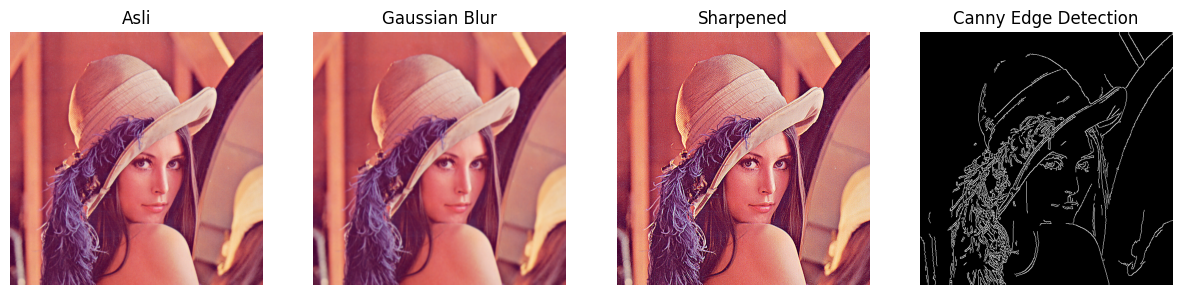

In [19]:
# Fungsi tampil berdampingan
def show_side_by_side(images, titles, figsize=(15,5)):
    plt.figure(figsize=figsize)

    for i, (img, title) in enumerate(zip(images, titles)):
        if len(img.shape) == 2:  # grayscale
            plt.subplot(1, len(images), i+1)
            plt.imshow(img, cmap="gray")
        else:  # color
            plt.subplot(1, len(images), i+1)
            plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))

        plt.title(title)
        plt.axis("off")

    plt.show()


img = cv.imread("/content/drive/MyDrive/Google Collab/Lenna.png")
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

blur = cv.GaussianBlur(img, (7,7), 1)
edges = cv.Canny(cv.cvtColor(img, cv.COLOR_BGR2GRAY), 100, 200)

sharpen_kernel = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]])
sharpened = cv.filter2D(img, -1, sharpen_kernel)

show_side_by_side(
    [img, blur, sharpened, edges],
    ["Asli", "Gaussian Blur", "Sharpened", "Canny Edge Detection"]
)

# Percobaan 2

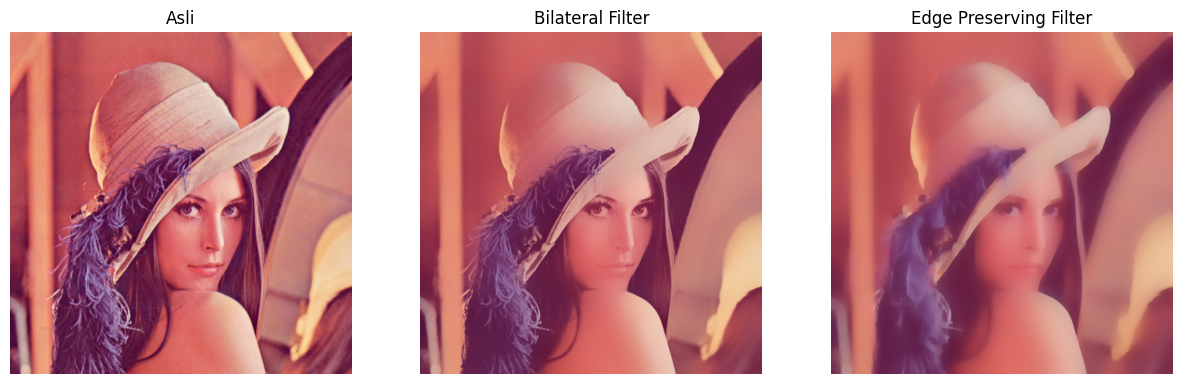

In [21]:
# Filter Modern dari OpenCV

# Bilateral Filter (edge-preserving)
bilateral = cv.bilateralFilter(img, 50, 100, 100)

# Edge Preserving Filter (alternatif Guided Filter)
edge_preserve = cv.edgePreservingFilter(
    img,
    flags=1,
    sigma_s=100,
    sigma_r=0.9
)

# Menampilkan hasil secara berdampingan
show_side_by_side(
    [img, bilateral, edge_preserve],
    ["Asli", "Bilateral Filter", "Edge Preserving Filter"]
)

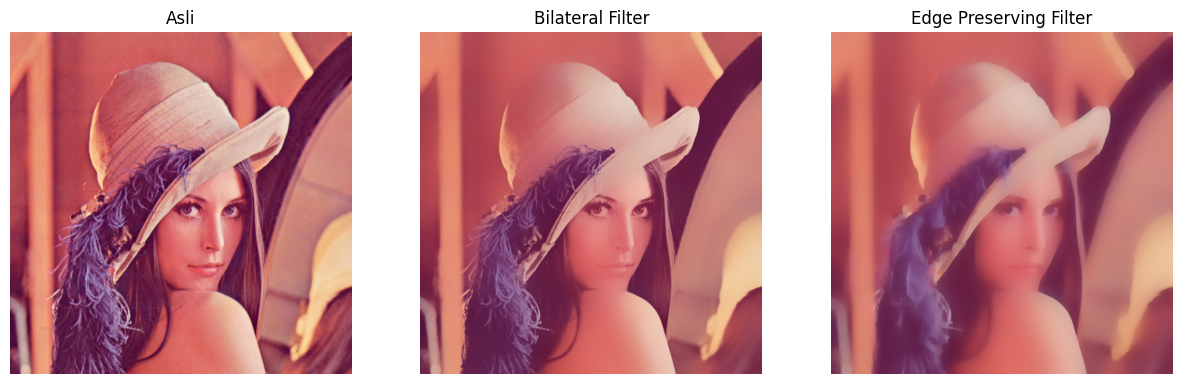

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
from google.colab.patches import cv2_imshow


# Fungsi tampil berdampingan
def show_side_by_side(images, titles, figsize=(15, 5)):
    plt.figure(figsize=figsize)

    for i, (img, title) in enumerate(zip(images, titles)):
        if len(img.shape) == 2:  # grayscale
            plt.subplot(1, len(images), i + 1)
            plt.imshow(img, cmap="gray")
        else:  # color
            plt.subplot(1, len(images), i + 1)
            plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))

        plt.title(title)
        plt.axis("off")

    plt.show()


# Membaca gambar
img = cv.imread(
    "/content/drive/MyDrive/Google Collab/Lenna.png"
)

# Bilateral Filter (edge-preserving)
bilateral = cv.bilateralFilter(img, 50, 100, 100)

# Edge Preserving Filter (alternatif Guided Filter)
edge_preserve = cv.edgePreservingFilter(
    img,
    flags=1,
    sigma_s=100,
    sigma_r=0.9
)

# Menampilkan hasil
show_side_by_side(
    [img, bilateral, edge_preserve],
    ["Asli", "Bilateral Filter", "Edge Preserving Filter"]
)

# Percobaan 3

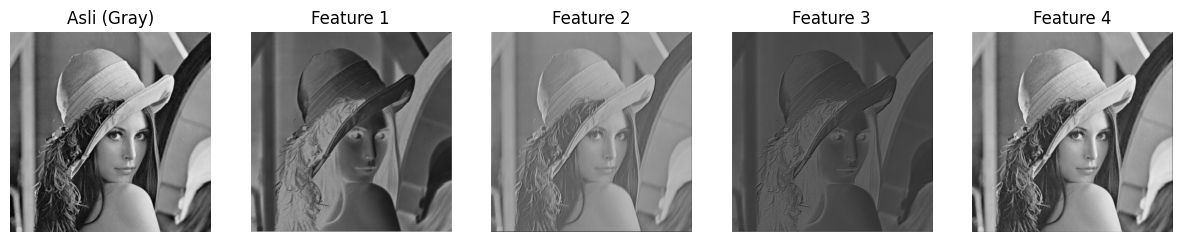

In [23]:
# Filter Feature Map yang digunakan pada CNN
# Lakukan running code bagian ini beberapa kali dan perhatikan hasilnya

import torch
import torch.nn as nn


class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(
            1, 4,
            kernel_size=3,
            stride=1,
            padding=1
        )

    def forward(self, x):
        return self.conv1(x)


model = SimpleCNN()

# Ubah gambar ke tensor
img_tensor = torch.tensor(
    img_gray,
    dtype=torch.float32
).unsqueeze(0).unsqueeze(0) / 255.0


# Hasil CNN
with torch.no_grad():
    features = model(img_tensor)


# Visualisasi feature maps
feature_maps = [
    features[0, i].numpy()
    for i in range(features.shape[1])
]

show_side_by_side(
    [img_gray] + feature_maps,
    ["Asli (Gray)"] +
    [f"Feature {i+1}" for i in range(len(feature_maps))]
)

# Percobaan 4

In [24]:
# ====================
# 1. Beauty Filter
# ====================

# Step 1: Smoothing kulit dengan bilateral filter
smooth = cv.bilateralFilter(
    img,
    d=15,
    sigmaColor=75,
    sigmaSpace=75
)

# Step 2: Unsharp masking (pertajam mata/bibir)
gaussian = cv.GaussianBlur(smooth, (0, 0), 3)
sharpened = cv.addWeighted(
    smooth,
    1.5,
    gaussian,
    -0.5,
    0
)

# Step 3: Brightness & contrast
alpha = 1.2  # contrast
beta = 15    # brightness

beauty = cv.convertScaleAbs(
    sharpened,
    alpha=alpha,
    beta=beta
)


# ====================
# 2. Old/Vintage Filter
# ====================

# Step 1: Sepia tone
sepia_kernel = np.array([
    [0.272, 0.534, 0.131],
    [0.349, 0.686, 0.168],
    [0.393, 0.769, 0.189]
])

sepia = cv.transform(img, sepia_kernel)
sepia = np.clip(sepia, 0, 255).astype(np.uint8)


# Step 2: Vignette
rows, cols = img.shape[:2]

kernel_x = cv.getGaussianKernel(cols, cols * 0.6)
kernel_y = cv.getGaussianKernel(rows, rows * 0.6)

kernel = kernel_y * kernel_x.T
mask = kernel / kernel.max()

vignette = np.copy(sepia)

for i in range(3):
    vignette[:, :, i] = vignette[:, :, i] * mask


# Step 3: Noise/Grain
noise = np.random.normal(
    0,
    15,
    vignette.shape
).astype(np.int16)

old_img = np.clip(
    vignette.astype(np.int16) + noise,
    0,
    255
).astype(np.uint8)

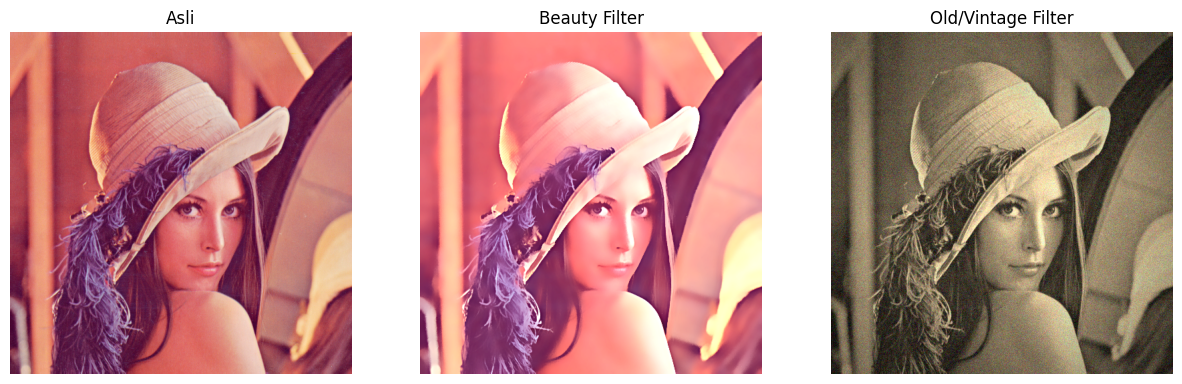

In [25]:
show_side_by_side(
    [img, beauty, old_img],
    ["Asli", "Beauty Filter", "Old/Vintage Filter"]
)

# Percobaan 5

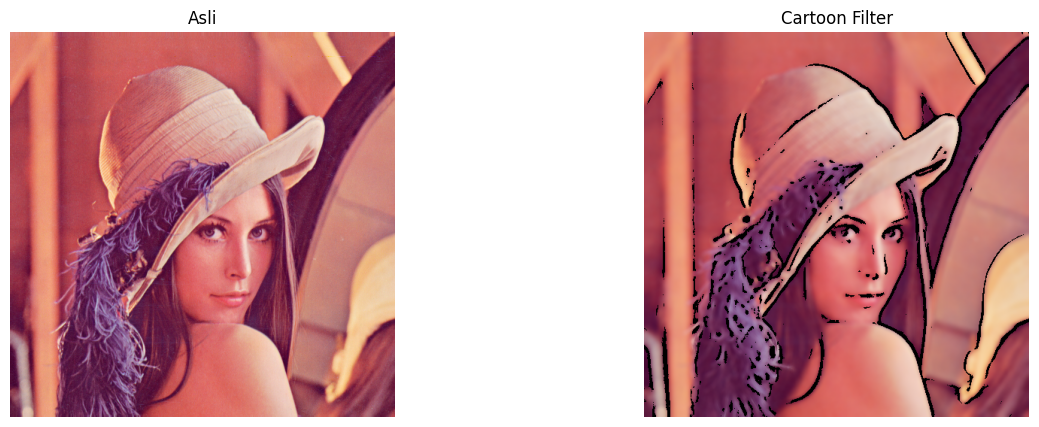

In [26]:
# Filter Anime / Cartoon

# Step 1: Edge detection
# Pakai median blur dulu agar gambar menjadi lebih halus
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

gray_blur = cv.medianBlur(gray, 7)

edges = cv.adaptiveThreshold(
    gray_blur,
    255,
    cv.ADAPTIVE_THRESH_MEAN_C,
    cv.THRESH_BINARY,
    9,
    9
)


# Step 2: Bilateral filter untuk smoothing warna
color = cv.bilateralFilter(
    img,
    d=9,
    sigmaColor=200,
    sigmaSpace=200
)


# Step 3: Gabungkan (cartoonize)
cartoon = cv.bitwise_and(
    color,
    color,
    mask=edges
)


# Tampilkan
show_side_by_side(
    [img, cartoon],
    ["Asli", "Cartoon Filter"]
)

# Percobaan 6

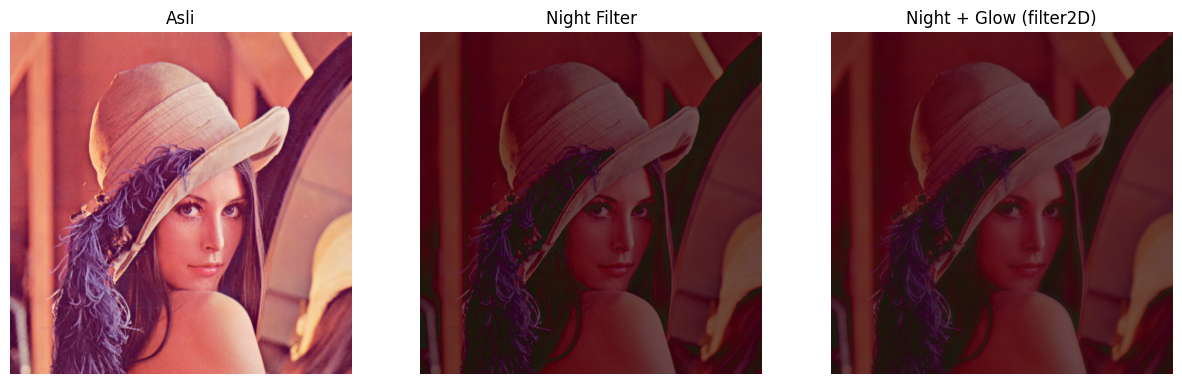

In [27]:
# Night Filter

img = cv.imread(
    "/content/drive/MyDrive/Google Collab/Lenna.png"
)

img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)


# Step 1: Gelapkan (contrast turun, brightness negatif)
night = cv.convertScaleAbs(
    img,
    alpha=0.6,
    beta=-40
)


# Step 2: Tambah bias biru
blue_tint = np.full_like(
    night,
    (50, 0, 100)
)  # BGR

night = cv.addWeighted(
    night,
    0.8,
    blue_tint,
    0.2,
    0
)


# Step 3: Efek glow di area terang dengan filter2D (blur kernel)
kernel = np.ones((15, 15), np.float32) / 225

glow = cv.filter2D(
    night,
    -1,
    kernel
)


# Kombinasikan asli + glow
night_glow = cv.addWeighted(
    night,
    0.7,
    glow,
    0.3,
    0
)


# Tampilkan hasil berdampingan
show_side_by_side(
    [img, night, night_glow],
    ["Asli", "Night Filter", "Night + Glow (filter2D)"]
)

# Percobaan 7

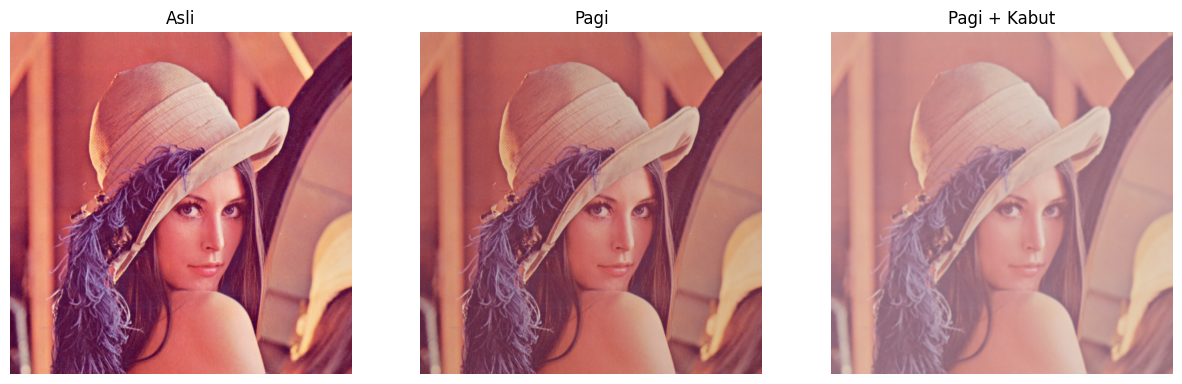

In [28]:
# Filter Suasana pagi dan Kabut
# =============================

# Step 1: Kurangi kontras & cerahkan
# =============================
alpha = 0.9    # contrast
beta = 20      # brightness

soft = cv.convertScaleAbs(
    img,
    alpha=alpha,
    beta=beta
)


# Step 2: Tambahkan warm tone (kemerahan / oranye)
# =============================
warm_tint = np.full_like(
    soft,
    (40, 70, 120)
)  # BGR

pagi = cv.addWeighted(
    soft,
    0.8,
    warm_tint,
    0.2,
    0
)


# Step 3: Tambahkan haze (kabut tipis) dengan filter2D
# =============================

# Kernel blur Gaussian-like untuk menciptakan efek kabut
kernel = cv.getGaussianKernel(3, 3)
kernel = kernel @ kernel.T

kabut = cv.filter2D(
    pagi,
    -1,
    kernel
)


# Tambah layer putih untuk kabut lebih nyata
white_layer = np.full_like(
    pagi,
    255
)

kabut = cv.addWeighted(
    kabut,
    0.7,
    white_layer,
    0.3,
    0
)


# Tampilkan hasil
show_side_by_side(
    [img, pagi, kabut],
    ["Asli", "Pagi", "Pagi + Kabut"]
)

# Praktikum

# NO 1

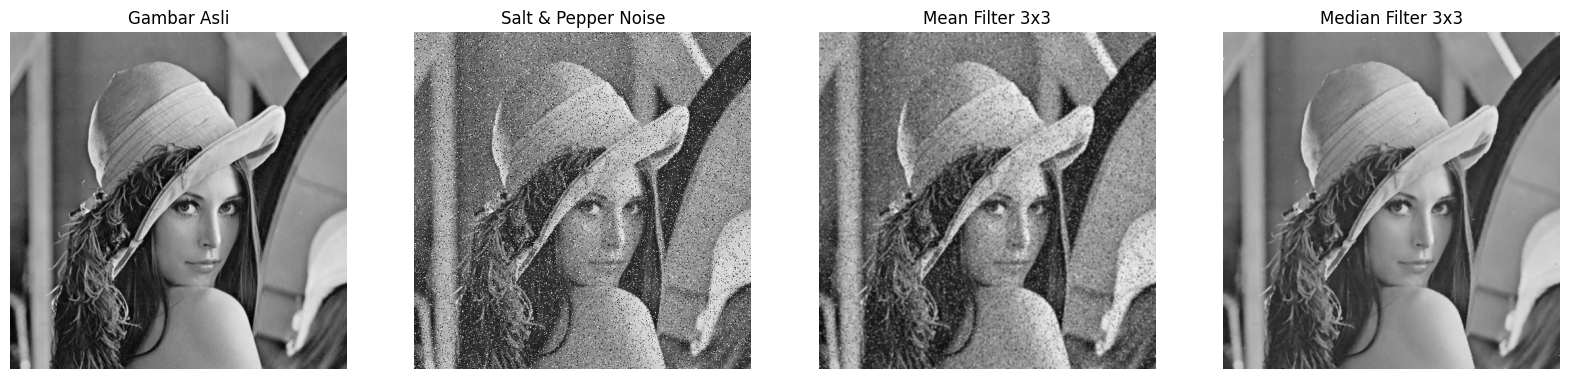

In [35]:
# ============================================
# TUGAS ANALISIS
# Mean Filter vs Median Filter
# pada Noise Salt and Pepper
# ============================================

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt


# Membaca gambar
img = cv.imread(
    "/content/drive/MyDrive/Google Collab/Lenna.png"
)

# Mengubah gambar menjadi grayscale
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)


# ============================================
# A. Menambahkan Salt and Pepper Noise
# ============================================

def salt_and_pepper(image, amount=0.05):
    noisy = image.copy()

    # Jumlah pixel yang diberi noise
    num_pixels = int(amount * image.size)

    # Salt (putih)
    coords = (
        np.random.randint(0, image.shape[0], num_pixels),
        np.random.randint(0, image.shape[1], num_pixels)
    )
    noisy[coords] = 255

    # Pepper (hitam)
    coords = (
        np.random.randint(0, image.shape[0], num_pixels),
        np.random.randint(0, image.shape[1], num_pixels)
    )
    noisy[coords] = 0

    return noisy


noisy_image = salt_and_pepper(
    img_gray,
    amount=0.05
)


# ============================================
# B. Mean Filter 3x3
# ============================================

mean_filter = cv.blur(
    noisy_image,
    (3, 3)
)


# ============================================
# C. Median Filter 3x3
# ============================================

median_filter = cv.medianBlur(
    noisy_image,
    3
)


# ============================================
# Menampilkan hasil perbandingan
# ============================================

show_side_by_side(
    [
        img_gray,
        noisy_image,
        mean_filter,
        median_filter
    ],
    [
        "Gambar Asli",
        "Salt & Pepper Noise",
        "Mean Filter 3x3",
        "Median Filter 3x3"
    ],
    figsize=(20, 5)
)

# NO 2

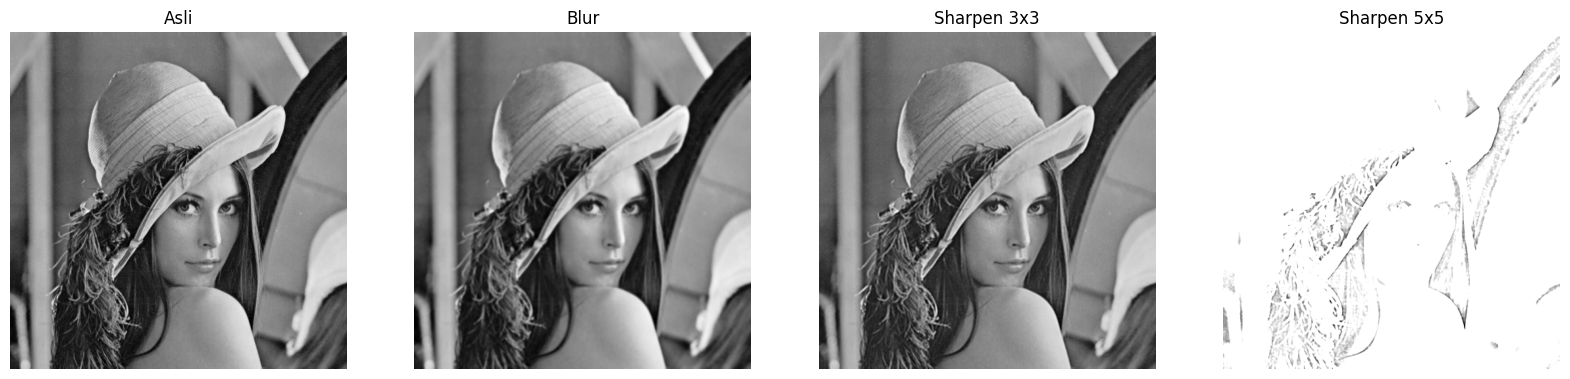

In [36]:
# ============================================
# TUGAS EVALUASI 2
# Perbandingan Kernel Sharpening 3x3 vs 5x5
# ============================================

import cv2 as cv
import numpy as np


# Membaca gambar
img = cv.imread(
    "/content/drive/MyDrive/Google Collab/Lenna.png"
)

# Ubah menjadi grayscale
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)


# ============================================
# B. Membuat gambar sedikit blur
# ============================================

blur = cv.GaussianBlur(
    img_gray,
    (5, 5),
    0
)


# ============================================
# A. Sharpening Kernel 3x3
# ============================================

kernel_3x3 = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
])


# ============================================
# A. Sharpening Kernel 5x5
# ============================================

kernel_5x5 = np.array([
    [0,  0, -1,  0,  0],
    [0, -1, -1, -1,  0],
    [-1, -1, 17, -1, -1],
    [0, -1, -1, -1,  0],
    [0,  0, -1,  0,  0]
])


# ============================================
# B. Terapkan sharpening
# ============================================

sharpen_3x3 = cv.filter2D(
    blur,
    -1,
    kernel_3x3
)

sharpen_5x5 = cv.filter2D(
    blur,
    -1,
    kernel_5x5
)


# ============================================
# Tampilkan perbandingan
# ============================================

show_side_by_side(
    [
        img_gray,
        blur,
        sharpen_3x3,
        sharpen_5x5
    ],
    [
        "Asli",
        "Blur",
        "Sharpen 3x3",
        "Sharpen 5x5"
    ],
    figsize=(20, 5)
)

# NO 3

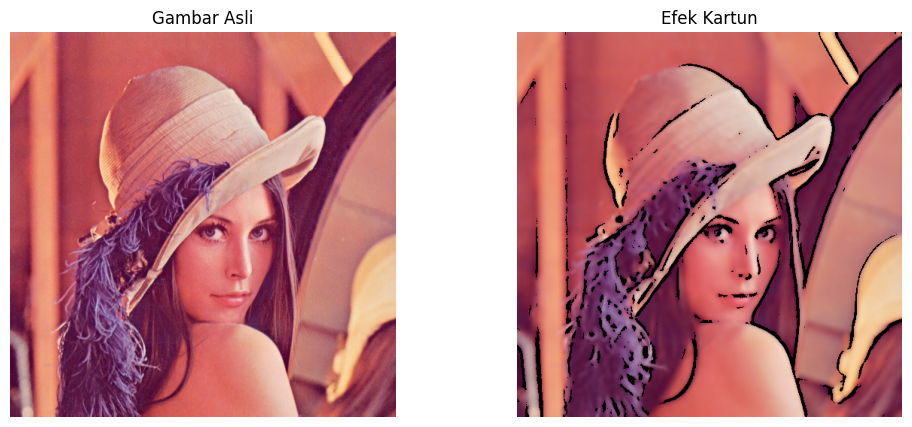

In [37]:
# ============================================
# TUGAS KREATIF 3
# Filter Kartun Sederhana
# ============================================

def kartun(image):

    # 1. Penghalusan warna menggunakan Bilateral Filter
    color = cv.bilateralFilter(
        image,
        d=9,
        sigmaColor=200,
        sigmaSpace=200
    )

    # 2. Deteksi garis tepi menggunakan Adaptive Thresholding
    gray = cv.cvtColor(
        image,
        cv.COLOR_BGR2GRAY
    )

    gray = cv.medianBlur(
        gray,
        7
    )

    edges = cv.adaptiveThreshold(
        gray,
        255,
        cv.ADAPTIVE_THRESH_MEAN_C,
        cv.THRESH_BINARY,
        9,
        9
    )

    # 3. Gabungkan warna dan garis tepi
    cartoon_image = cv.bitwise_and(
        color,
        color,
        mask=edges
    )

    return cartoon_image


# Membuat efek kartun
hasil_kartun = kartun(img)


# Menampilkan gambar asli dan hasil kartun
show_side_by_side(
    [img, hasil_kartun],
    ["Gambar Asli", "Efek Kartun"],
    figsize=(12, 5)
)

array([[[128, 137, 225],
        [127, 137, 225],
        [125, 136, 225],
        ...,
        [117, 137, 225],
        [114, 135, 224],
        [  0,   0,   0]],

       [[128, 137, 225],
        [127, 137, 225],
        [125, 136, 225],
        ...,
        [116, 136, 224],
        [114, 134, 223],
        [  0,   0,   0]],

       [[127, 137, 225],
        [126, 137, 225],
        [124, 136, 225],
        ...,
        [114, 132, 221],
        [112, 130, 219],
        [109, 126, 216]],

       ...,

       [[ 60,  26,  89],
        [ 60,  26,  90],
        [ 61,  26,  91],
        ...,
        [ 79,  66, 167],
        [ 79,  67, 170],
        [ 78,  67, 172]],

       [[ 60,  25,  89],
        [ 60,  25,  89],
        [ 60,  25,  90],
        ...,
        [ 80,  68, 171],
        [ 79,  68, 173],
        [ 80,  68, 174]],

       [[ 60,  25,  89],
        [ 60,  25,  90],
        [ 60,  25,  89],
        ...,
        [ 80,  68, 171],
        [ 80,  69, 174],
        [ 80,  68, 175]]], dtype=uint8)
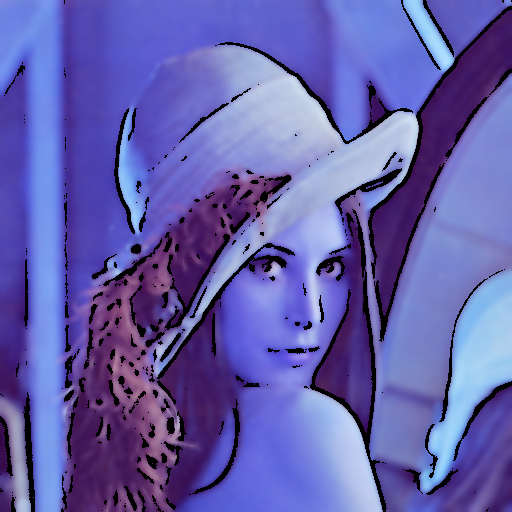

In [32]:
cv.bitwise_and(color, color, mask=edges)